In [ ]:
!pip install kaggle

# Create folder
!mkdir -p dogsvscats_dataset

# Download dataset
!kaggle datasets download -d princelv84/dogsvscats -p dogsvscats_dataset

# Unzip dataset
!unzip dogsvscats_dataset/dogsvscats.zip -d dogsvscats_dataset

Streaming output truncated to the last 5000 lines.
  inflating: dogsvscats_dataset/train/dogs/dog.4419.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.442.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4420.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4421.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4422.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4424.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4425.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4426.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4427.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4431.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4433.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4436.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4438.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4439.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.444.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4440.jpg  
  inflating: dogsvscats

In [ ]:
import tensorflow  # used for building and running deep learning models
from tensorflow import keras  # provides Keras tools for creating neural networks
from keras import Sequential  # creates a model by stacking layers sequentially
from keras.layers import Dense, Flatten  # Flatten converts data to 1D and Dense creates fully connected layers
from keras.applications.vgg16 import VGG16  # loads the pre-trained VGG16 model for image feature extraction

In [ ]:
conv_base = VGG16(  # creates the VGG16 convolutional base
    weights='imagenet',  # uses pre-trained ImageNet weights
    include_top=False,  # removes the original classification layers
    input_shape=(150,150,3)  # sets input image size to 150x150 with 3 color channels
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


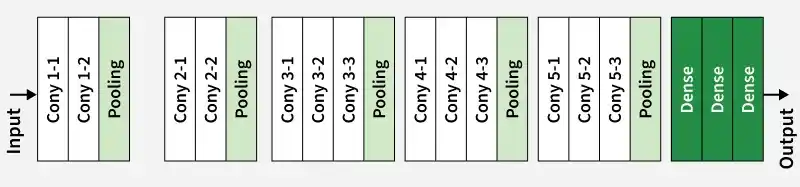

In [ ]:
conv_base.trainable = True  # makes all VGG16 layers trainable initially

set_trainable = False  # starts by keeping the layers frozen

for layer in conv_base.layers:  # goes through each VGG16 layer one by one

    if layer.name == 'block5_conv1':  # checks if the current layer is block5_conv1
        set_trainable = True  # from this layer onward, allow layers to be trained

    if set_trainable:  # checks whether we have reached block5_conv1
        layer.trainable = True  # allows this layer to update its weights
    else:
        layer.trainable = False  # keeps this layer's weights frozen

for layer in conv_base.layers:  # goes through all VGG16 layers again
    print(layer.name, layer.trainable)  # prints each layer's name and whether it is trainable

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
model = Sequential()  # creates a sequential model

model.add(conv_base)  # adds the VGG16 convolutional base

model.add(Flatten())  # converts the feature maps into a 1D vector

model.add(Dense(256, activation='relu'))  # adds a fully connected layer with 256 neurons

model.add(Dense(1, activation='sigmoid'))  # adds the output layer for binary classification

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img  # used for image preprocessing, conversion, and loading

In [17]:
batch_size = 32  # sets the number of images processed in each batch

train_datagen = ImageDataGenerator(  # creates image augmentation for training
    rescale=1./255,  # scales pixel values from 0-255 to 0-1
    shear_range=0.2,  # applies random shearing to images
    zoom_range=0.2,  # applies random zooming to images
    horizontal_flip=True  # randomly flips images horizontally
)

test_datagen = ImageDataGenerator(  # creates preprocessing for validation images
    rescale=1./255  # scales pixel values from 0-255 to 0-1
)

train_ds = train_datagen.flow_from_directory(  # loads training images
    '/content/dogsvscats_dataset/train',  # path to training images
    target_size=(150, 150),  # resizes images to 150x150
    batch_size=batch_size,  # loads 32 images in each batch
    class_mode='binary'  # uses binary labels for cats and dogs
)

validation_ds = test_datagen.flow_from_directory(  # loads validation images
    '/content/dogsvscats_dataset/test',  # path to validation images
    target_size=(150, 150),  # resizes images to 150x150
    batch_size=batch_size,  # loads 32 images in each batch
    class_mode='binary'  # uses binary labels for cats and dogs
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [19]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

In [20]:
history = model.fit(train_ds,epochs=1,validation_data=validation_ds)

625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 292ms/step - accuracy: 0.8900 - loss: 0.2590 - val_accuracy: 0.9330 - val_loss: 0.1606


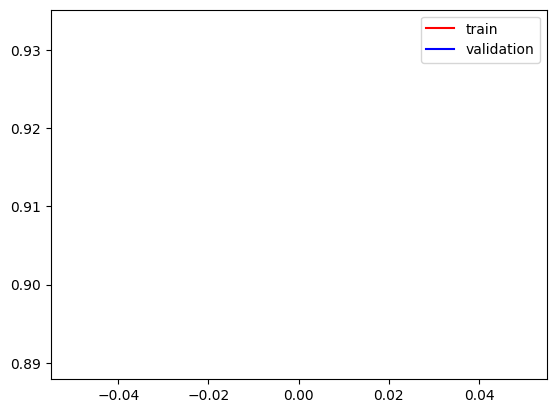

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

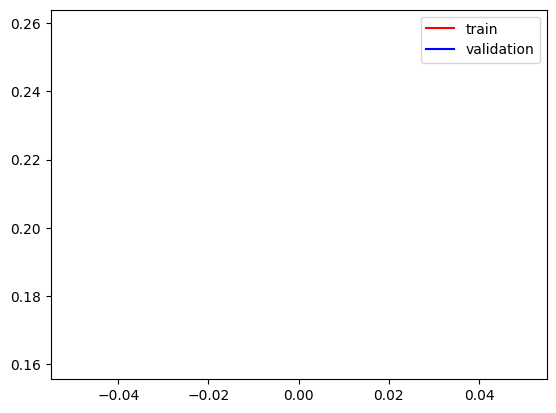

In [22]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [24]:
import numpy as np  # used for numerical operations
from tensorflow.keras.preprocessing import image  # used to load and preprocess images

img = image.load_img('/content/images (2).jpg', target_size=(150, 150))  # loads and resizes the new image

img_array = image.img_to_array(img)  # converts the image into an array

img_array = img_array / 255.0  # scales pixel values from 0-255 to 0-1

img_array = np.expand_dims(img_array, axis=0)  # adds the batch dimension

prediction = model.predict(img_array)  # predicts whether the image is a cat or dog

if prediction[0][0] > 0.5:  # checks the prediction probability
    print("Dog")  # prediction is Dog
else:
    print("Cat")  # prediction is Cat

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Dog
